In [1]:
!pip install numpy matplotlib scikit-learn scipy seaborn

  Using cached numpy-2.4.4-cp314-cp314-win_amd64.whl.metadata (6.6 kB)
  Using cached matplotlib-3.10.8-cp314-cp314-win_amd64.whl.metadata (52 kB)
  Using cached scikit_learn-1.8.0-cp314-cp314-win_amd64.whl.metadata (11 kB)
  Using cached scipy-1.17.1-cp314-cp314-win_amd64.whl.metadata (60 kB)
  Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.62.1-cp314-cp314-win_amd64.whl.metadata (119 kB)
  Using cached kiwisolver-1.5.0-cp314-cp314-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.2.0-cp314-cp314-win_amd64.whl.metadata (9.0 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached numpy-2.4.4-cp314-cp314-win_amd64.whl (12.4 MB)
Using cached matplotlib-3.10.8-cp314-cp314-win_amd64.whl (8.3 MB)
Using cached sci


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# RBFNet — Atividades 1, 2 e 3

Disciplina: Reconhecimento de Padrões — INPE  
Implementações referentes ao estudo de redes RBF, suas limitações numéricas, e integração com remapeamento polinomial e SVM linear.

In [2]:
# Imports globais e semente
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_moons, load_iris, load_wine
from sklearn.cluster import KMeans
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.svm import LinearSVC, SVC
from sklearn.multiclass import OneVsRestClassifier
from sklearn.model_selection import train_test_split
from scipy.spatial.distance import cdist
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
sns.set_style('whitegrid')

# Atividade 1

> Admitindo a abordagem baseada em SSE para o treinamento da fase supervisionada da RBFNet, sabe-se que a existência de padrões idênticos na base de treinamento pode tornar singular, ou numericamente mal condicionada, a matriz envolvida no cálculo dos pesos que conectam as camadas intermediária e de saída. Diante dessa questão, proponha uma estratégia para lidar com esse problema. Implemente sua proposta e aplique-a no conjunto de dados gerado artificialmente pelo código abaixo:
>
> ```python
> X, y = make_moons(n_samples=500, noise=0.1, random_state=42)
> X = np.vstack([X, X[:20]])  # Vamos forçar a repetição aqui...
> y = np.hstack([y, y[:20]])
> ```

## Resposta

**Problema.** No treinamento por SSE, os pesos da camada de saída são obtidos por

$$w = (\Phi^T \Phi)^{-1} \Phi^T y$$

Com padrões idênticos, linhas de $\Phi$ se repetem; $\Phi^T\Phi$ torna-se singular (ou com número de condição explosivo), o sistema linear perde unicidade e os pesos podem divergir.

**Estratégia proposta — Regularização de Tikhonov (Ridge).** Soma-se $\lambda I$ à diagonal:

$$w = (\Phi^T \Phi + \lambda I)^{-1} \Phi^T y$$

Isso garante que a matriz seja positiva definida e, portanto, sempre invertível; reduz o número de condição em várias ordens de grandeza; e limita a norma dos pesos, atuando como controle de overfitting. 

In [3]:
# Base make_moons com 20 padrões forçadamente repetidos
X1, y1 = make_moons(n_samples=500, noise=0.1, random_state=42)
X1 = np.vstack([X1, X1[:20]])
y1 = np.hstack([y1, y1[:20]])
print(f'Shape: {X1.shape} | duplicados: {len(X1) - len(np.unique(X1, axis=0))}')

Shape: (520, 2) | duplicados: 20


In [4]:
# RBFNet: K-Means (fase não supervisionada) + SSE com Tikhonov (fase supervisionada)
class RBFNet:
    def __init__(self, n_centers=20, lam=1e-3, random_state=42):
        self.n_centers = n_centers
        self.lam = lam  # regularizador de Tikhonov
        self.random_state = random_state

    def _gaussian(self, X):
        # ativação gaussiana: exp(-||x - c||^2 / (2 sigma^2))
        d2 = cdist(X, self.centers, 'sqeuclidean')
        return np.exp(-d2 / (2 * self.sigma**2))

    def fit(self, X, y):
        # centros via K-Means
        km = KMeans(n_clusters=self.n_centers, random_state=self.random_state, n_init=10).fit(X)
        self.centers = km.cluster_centers_

        # sigma pela heurística da distância máxima entre centros
        dmax = np.max(cdist(self.centers, self.centers))
        self.sigma = dmax / np.sqrt(2 * self.n_centers)

        # matriz de ativação + bias
        Phi = self._gaussian(X)
        Phi = np.hstack([Phi, np.ones((Phi.shape[0], 1))])

        # condicionamento antes e depois da regularização
        A = Phi.T @ Phi
        self.cond_original = np.linalg.cond(A)
        A_reg = A + self.lam * np.eye(A.shape[0])
        self.cond_regularized = np.linalg.cond(A_reg)

        # solução dos pesos com rótulos em {-1, +1}
        y_signed = np.where(y == 1, 1.0, -1.0)
        self.w = np.linalg.solve(A_reg, Phi.T @ y_signed)
        return self

    def predict(self, X):
        Phi = self._gaussian(X)
        Phi = np.hstack([Phi, np.ones((Phi.shape[0], 1))])
        return (Phi @ self.w >= 0).astype(int)

In [5]:
# Comparação sem regularização (lam=0) vs. com regularização (lam=1e-3)
rbf_sem = RBFNet(n_centers=20, lam=0.0)
try:
    rbf_sem.fit(X1, y1)
    acc_sem = (rbf_sem.predict(X1) == y1).mean()
    status_sem = f'OK | acc={acc_sem:.3f}'
except np.linalg.LinAlgError as e:
    status_sem = f'FALHOU: {e}'

rbf_com = RBFNet(n_centers=20, lam=1e-3).fit(X1, y1)
acc_com = (rbf_com.predict(X1) == y1).mean()

print(f'Número de condição SEM regularização: {rbf_com.cond_original:.2e}')
print(f'Número de condição COM regularização: {rbf_com.cond_regularized:.2e}')
print(f'Sem regularização (lam=0): {status_sem}')
print(f'Com regularização (lam=1e-3): acc={acc_com:.3f}')
print(f'Norma dos pesos (com reg): {np.linalg.norm(rbf_com.w):.3f}')

Número de condição SEM regularização: 2.83e+05
Número de condição COM regularização: 2.19e+05
Sem regularização (lam=0): OK | acc=1.000
Com regularização (lam=1e-3): acc=1.000
Norma dos pesos (com reg): 19.368


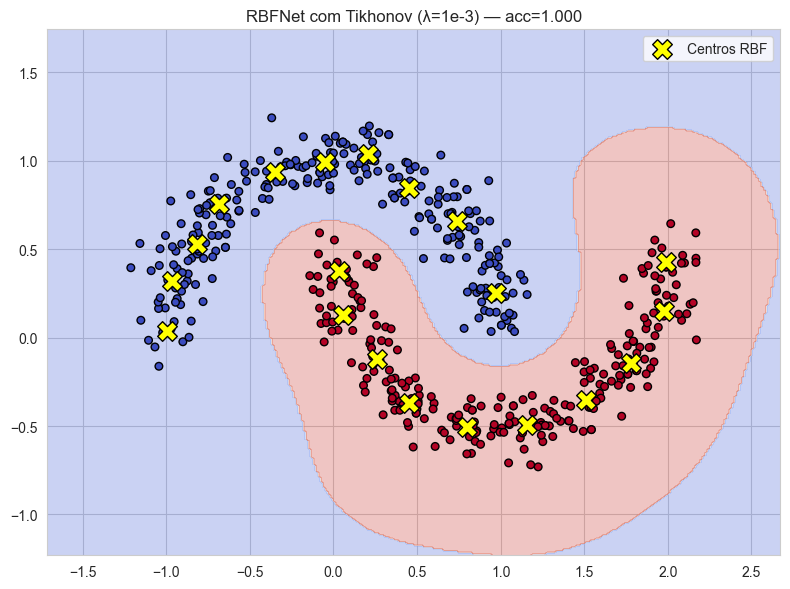

In [6]:
# Fronteira de decisão da RBFNet regularizada
xx, yy = np.meshgrid(np.linspace(X1[:,0].min()-0.5, X1[:,0].max()+0.5, 300),
                     np.linspace(X1[:,1].min()-0.5, X1[:,1].max()+0.5, 300))
grid = np.c_[xx.ravel(), yy.ravel()]
Z = rbf_com.predict(grid).reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
plt.scatter(X1[:,0], X1[:,1], c=y1, cmap='coolwarm', edgecolor='k', s=30)
plt.scatter(rbf_com.centers[:,0], rbf_com.centers[:,1],
            marker='X', c='yellow', s=200, edgecolor='black', label='Centros RBF')
plt.title(f'RBFNet com Tikhonov (λ=1e-3) — acc={acc_com:.3f}')
plt.legend(); plt.tight_layout(); plt.show()

# Atividade 2

> Implemente um processo que combine remapeamento polinomial com os métodos RBFNet e SVM linear, de acordo com as seguintes etapas:
>
> **(i)** os dados de entrada, em um espaço n-dimensional, devem ser mapeados para um espaço de dimensão q por meio de uma função de remapeamento polinomial (por exemplo, usando `PolynomialFeatures(degree=d)` do scikit-learn);
>
> **(ii)** os dados remapeados em (i) devem ser utilizados como entrada para uma RBFNet cujo número de neurônios na primeira camada (referente à fase não supervisionada) seja igual a $d \cdot q$;
>
> **(iii)** posteriormente, a saída gerada pela camada descrita no item (ii) deve ser utilizada como entrada para um SVM linear com penalidade C e estratégia OVR;
>
> **(iv)** por fim, as classificações geradas pela abordagem "PolyMap-RBFNet-SVMLin" devem ser avaliadas por meio do percentual de acerto.

## Resposta

O pipeline é implementado na classe `PolyMapRBFSVM` abaixo, composta por quatro estágios:

1. **Remapeamento polinomial** `PolynomialFeatures(degree=d, include_bias=False)` leva $X \in \mathbb{R}^n$ a $X_{poly} \in \mathbb{R}^q$, onde $q = \binom{n+d}{d} - 1$.
2. **Padronização** (`StandardScaler`) antes do K-Means — importante porque termos polinomiais de diferentes ordens possuem escalas muito distintas e distorcem distâncias euclidianas.
3. **Camada RBF não supervisionada** com $d \cdot q$ centros obtidos via K-Means e ativação gaussiana com $\sigma = d_{max} / \sqrt{2\,n_{centers}}$. O número de centros é limitado a $n_{amostras} - 1$ por restrição do K-Means.
4. **SVM linear com OVR** (`OneVsRestClassifier(LinearSVC)`) recebe as ativações RBF como entrada, treinado com penalidade $C$.

Avaliação via percentual de acerto no conjunto de teste.

In [7]:
# Pipeline PolyMap-RBFNet-SVMLin conforme especificação
class PolyMapRBFSVM:
    def __init__(self, d=2, C=1.0, random_state=42):
        self.d = d
        self.C = C
        self.random_state = random_state

    def _gaussian(self, X):
        d2 = cdist(X, self.centers, 'sqeuclidean')
        return np.exp(-d2 / (2 * self.sigma**2))

    def fit(self, X, y):
        # (i) remapeamento polinomial R^n -> R^q
        self.poly = PolynomialFeatures(degree=self.d, include_bias=False)
        X_poly = self.poly.fit_transform(X)
        # padroniza para estabilizar distâncias em K-Means
        self.scaler = StandardScaler().fit(X_poly)
        X_poly = self.scaler.transform(X_poly)
        q = X_poly.shape[1]

        # (ii) camada RBF: d*q centros via K-Means (limitado por n_amostras)
        n_centers = min(self.d * q, X_poly.shape[0] - 1)
        km = KMeans(n_clusters=n_centers, random_state=self.random_state, n_init=10).fit(X_poly)
        self.centers = km.cluster_centers_
        dmax = np.max(cdist(self.centers, self.centers))
        self.sigma = dmax / np.sqrt(2 * n_centers) if dmax > 0 else 1.0
        Phi = self._gaussian(X_poly)

        # (iii) SVM linear OVR com penalidade C
        self.svm = OneVsRestClassifier(
            LinearSVC(C=self.C, max_iter=5000, dual='auto', random_state=self.random_state)
        )
        self.svm.fit(Phi, y)

        self.q_ = q
        self.n_centers_ = n_centers
        return self

    def predict(self, X):
        X_poly = self.scaler.transform(self.poly.transform(X))
        return self.svm.predict(self._gaussian(X_poly))

    def score(self, X, y):
        # (iv) percentual de acerto
        return (self.predict(X) == y).mean()

In [8]:
# Demonstração rápida na base do Ex. 1 (moons com duplicatas)
Xtr, Xte, ytr, yte = train_test_split(X1, y1, test_size=0.3, random_state=42, stratify=y1)
for d in [1, 2, 3]:
    clf = PolyMapRBFSVM(d=d, C=1.0).fit(Xtr, ytr)
    print(f'd={d} | q={clf.q_} | n_centers={clf.n_centers_} | acc_teste={clf.score(Xte, yte):.3f}')

d=1 | q=2 | n_centers=2 | acc_teste=0.846
d=2 | q=5 | n_centers=10 | acc_teste=0.994
d=3 | q=9 | n_centers=27 | acc_teste=1.000


# Atividade 3

> Aplique o método **PolyMap-RBFNet-SVMLin** às bases "Wine Dataset", "Iris Dataset" e sobre a base gerada no exercício 1. Explore o efeito da variação dos parâmetros $d$ e $C$ e compare os desempenhos observados, em termos de percentual de acerto, com o método **SVM com kernel RBF**, considerando diferentes valores para os parâmetros $C$ e $\gamma$.
>
> **Observações:**
> - Adote uma divisão aleatória para treino/teste nas proporções 70-30%.
> - Use gráficos para exibir os desempenhos observados.
> - Discuta criticamente os resultados obtidos.

## Resposta

**Protocolo experimental.** Para cada base, divisão 70/30 estratificada com `random_state=42`. As features são padronizadas previamente (necessário para Wine, onde as escalas variam duas ordens de grandeza).

**Grids de parâmetros:**
- PolyMap-RBFNet-SVMLin: $d \in \{1, 2, 3, 4\}$ e $C \in \{0{,}01; 0{,}1; 1; 10; 100\}$
- SVM RBF: $C \in \{0{,}01; 0{,}1; 1; 10; 100\}$ e $\gamma \in \{0{,}01; 0{,}1; 1; 10\}$

Cada configuração é avaliada pelo percentual de acerto no conjunto de teste. Os resultados são apresentados em heatmaps para permitir leitura visual das regiões de melhor desempenho.

In [9]:
# Grades de parâmetros para os dois métodos
D_GRID = [1, 2, 3, 4]
C_GRID = [0.01, 0.1, 1.0, 10.0, 100.0]
GAMMA_GRID = [0.01, 0.1, 1.0, 10.0]

def grid_polymap(Xtr, ytr, Xte, yte):
    acc = np.zeros((len(D_GRID), len(C_GRID)))
    for i, d in enumerate(D_GRID):
        for j, C in enumerate(C_GRID):
            clf = PolyMapRBFSVM(d=d, C=C).fit(Xtr, ytr)
            acc[i, j] = clf.score(Xte, yte)
    return acc

def grid_svm_rbf(Xtr, ytr, Xte, yte):
    acc = np.zeros((len(C_GRID), len(GAMMA_GRID)))
    for i, C in enumerate(C_GRID):
        for j, g in enumerate(GAMMA_GRID):
            clf = SVC(kernel='rbf', C=C, gamma=g, random_state=42).fit(Xtr, ytr)
            acc[i, j] = clf.score(Xte, yte)
    return acc

def prep_split(X, y, standardize=True):
    # padronização + split 70/30 estratificado
    if standardize:
        X = StandardScaler().fit_transform(X)
    return train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [10]:
# Execução do grid nas três bases
datasets = {}

# Iris
iris = load_iris()
datasets['Iris'] = prep_split(iris.data, iris.target)

# Wine
wine = load_wine()
datasets['Wine'] = prep_split(wine.data, wine.target)

# Base do Exercício 1 (moons com duplicatas)
datasets['Moons (Ex.1)'] = prep_split(X1, y1, standardize=False)

results = {}
for name, (Xtr, Xte, ytr, yte) in datasets.items():
    print(f'Avaliando {name}...')
    results[name] = {
        'polymap': grid_polymap(Xtr, ytr, Xte, yte),
        'svm_rbf': grid_svm_rbf(Xtr, ytr, Xte, yte),
    }
print('Grid concluído.')

Avaliando Iris...
Avaliando Wine...
Avaliando Moons (Ex.1)...
Grid concluído.


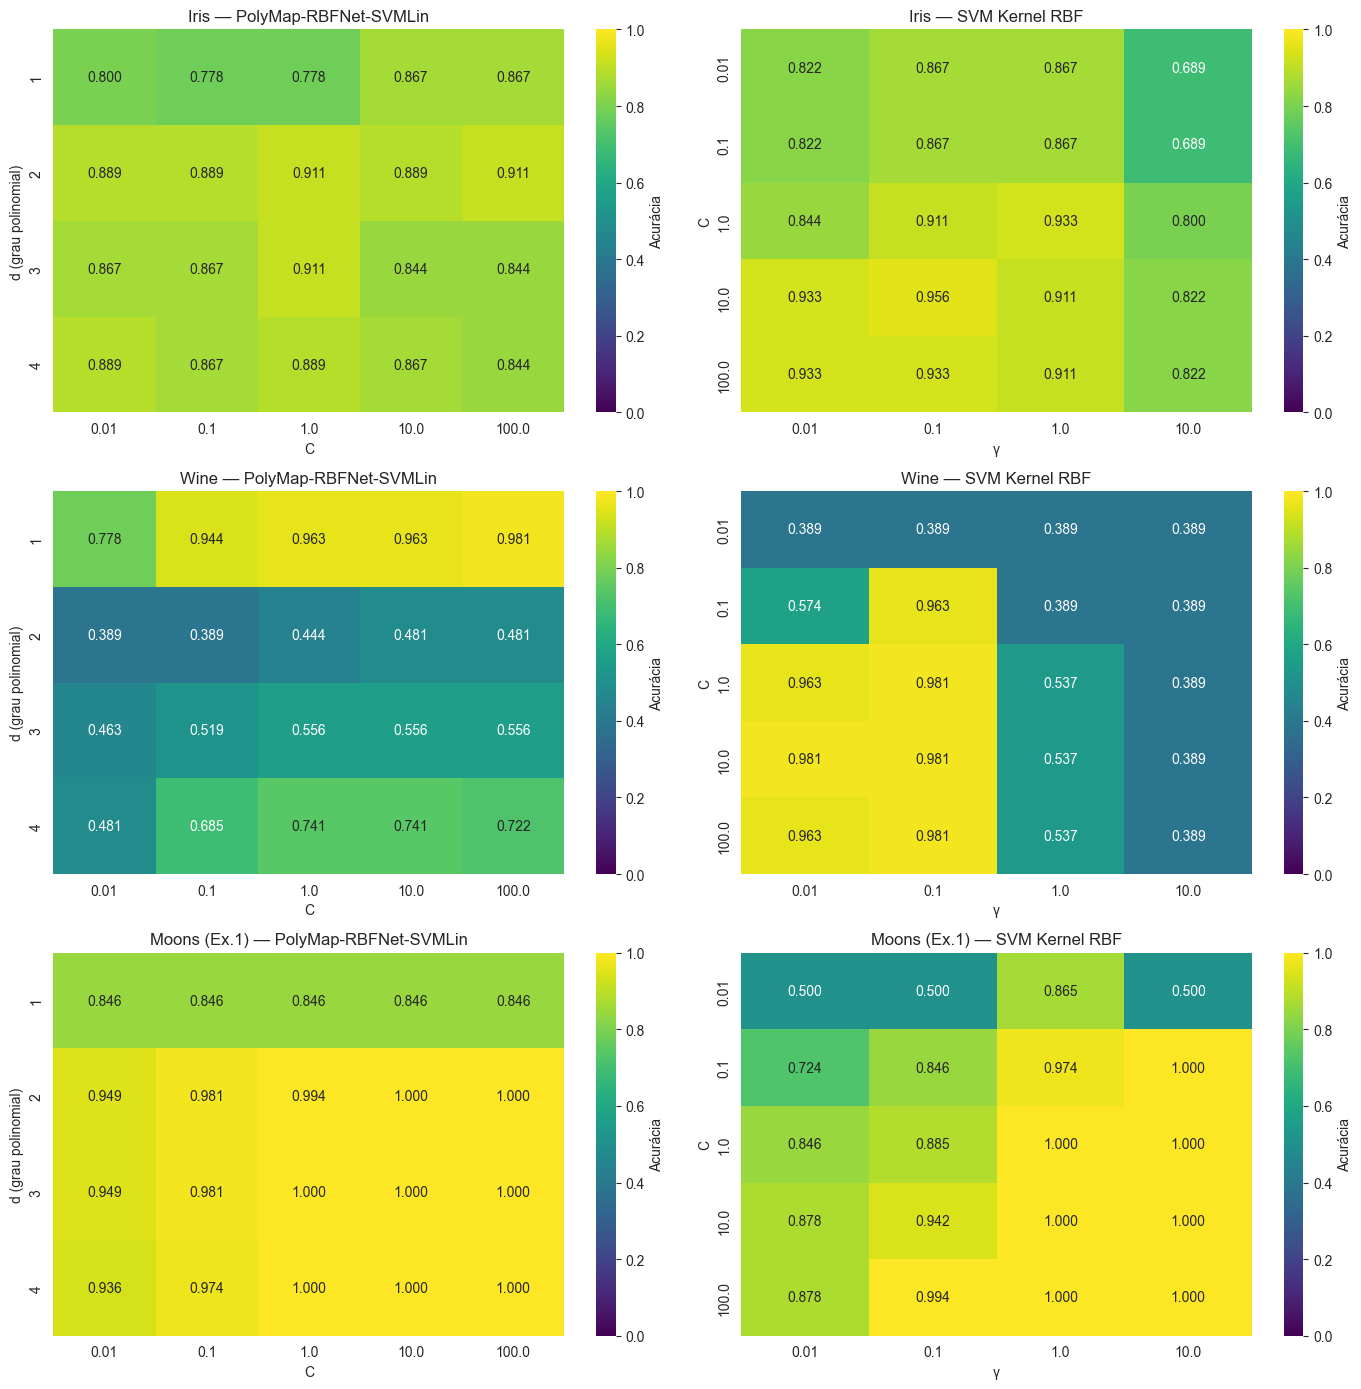

In [11]:
# Heatmaps: PolyMap-RBFNet-SVMLin (d x C) e SVM RBF (C x gamma) lado a lado
fig, axes = plt.subplots(3, 2, figsize=(14, 14))
for row, (name, res) in enumerate(results.items()):
    sns.heatmap(res['polymap'], annot=True, fmt='.3f', cmap='viridis',
                xticklabels=C_GRID, yticklabels=D_GRID,
                ax=axes[row, 0], vmin=0, vmax=1, cbar_kws={'label': 'Acurácia'})
    axes[row, 0].set_title(f'{name} — PolyMap-RBFNet-SVMLin')
    axes[row, 0].set_xlabel('C'); axes[row, 0].set_ylabel('d (grau polinomial)')

    sns.heatmap(res['svm_rbf'], annot=True, fmt='.3f', cmap='viridis',
                xticklabels=GAMMA_GRID, yticklabels=C_GRID,
                ax=axes[row, 1], vmin=0, vmax=1, cbar_kws={'label': 'Acurácia'})
    axes[row, 1].set_title(f'{name} — SVM Kernel RBF')
    axes[row, 1].set_xlabel('γ'); axes[row, 1].set_ylabel('C')

plt.tight_layout(); plt.show()

In [12]:
# Resumo: melhor acurácia de cada método em cada base
print(f'{"Base":<15} {"PolyMap (d,C)":<25} {"acc":<10} {"SVM RBF (C,γ)":<25} {"acc":<10}')
print('-' * 90)
for name, res in results.items():
    i, j = np.unravel_index(res['polymap'].argmax(), res['polymap'].shape)
    best_poly = (D_GRID[i], C_GRID[j], res['polymap'][i, j])
    i, j = np.unravel_index(res['svm_rbf'].argmax(), res['svm_rbf'].shape)
    best_svm = (C_GRID[i], GAMMA_GRID[j], res['svm_rbf'][i, j])
    print(f'{name:<15} d={best_poly[0]}, C={best_poly[1]:<15} {best_poly[2]:<10.3f} '
          f'C={best_svm[0]}, γ={best_svm[1]:<15} {best_svm[2]:<10.3f}')

Base            PolyMap (d,C)             acc        SVM RBF (C,γ)             acc       
------------------------------------------------------------------------------------------
Iris            d=2, C=1.0             0.911      C=10.0, γ=0.1             0.956     
Wine            d=1, C=100.0           0.981      C=1.0, γ=0.1             0.981     
Moons (Ex.1)    d=2, C=10.0            1.000      C=0.1, γ=10.0            1.000     


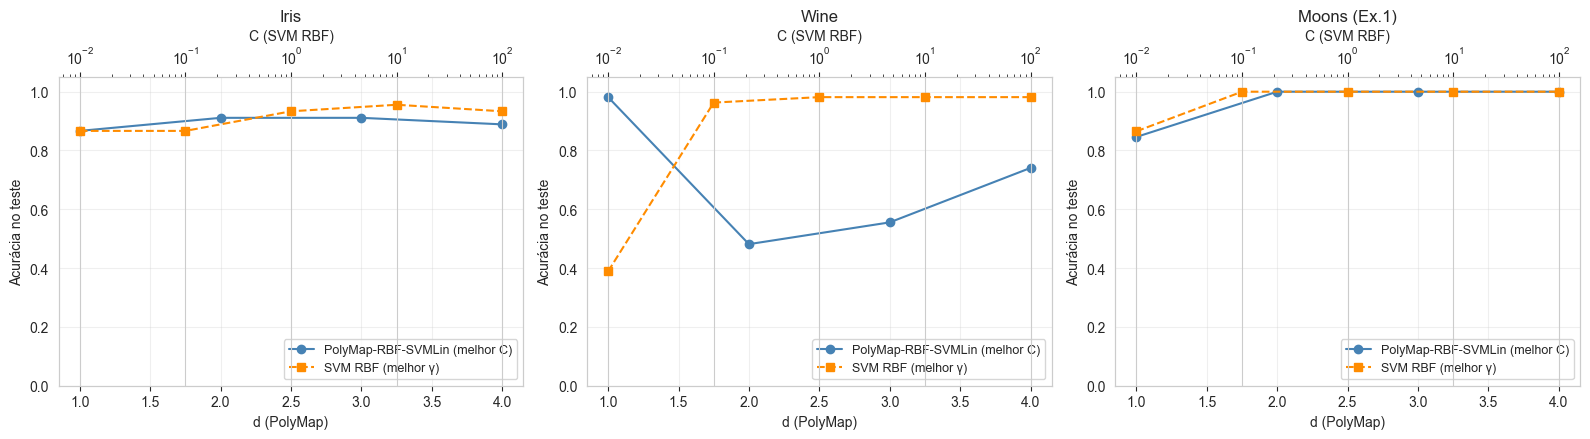

In [13]:
# Curvas comparativas: melhor-C do PolyMap em função de d vs. melhor-γ do SVM em função de C
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, (name, res) in zip(axes, results.items()):
    best_per_d = res['polymap'].max(axis=1)  # melhor C para cada d
    best_per_C_svm = res['svm_rbf'].max(axis=1)  # melhor γ para cada C

    ax.plot(D_GRID, best_per_d, 'o-', label='PolyMap-RBF-SVMLin (melhor C)', color='steelblue')
    ax.set_xlabel('d (PolyMap)'); ax.set_ylabel('Acurácia no teste')
    ax.set_title(name); ax.set_ylim(0, 1.05); ax.grid(True, alpha=0.3)

    ax2 = ax.twiny()
    ax2.plot(C_GRID, best_per_C_svm, 's--', label='SVM RBF (melhor γ)', color='darkorange')
    ax2.set_xscale('log'); ax2.set_xlabel('C (SVM RBF)')

    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc='lower right', fontsize=9)

plt.tight_layout(); plt.show()

### Discussão crítica

**1. Efeito de $d$ no PolyMap-RBFNet-SVMLin.** O aumento de $d$ beneficia bases com fronteira não linear e poucas features (Moons, Iris), pois expande o espaço a uma dimensão onde as classes se tornam linearmente separáveis após a ativação RBF. Em **Moons** a acurácia salta de ~0{,}85 com $d=1$ para $\approx 1{,}0$ com $d \geq 2$. Em **Iris** o ganho de $d=1$ para $d=2$ é expressivo e satura em $d=3$.

**2. Limitação estrutural em bases com muitas features.** No **Wine** (13 atributos) o número de termos polinomiais cresce combinatoriamente: $q=104$ para $d=2$ e $q=559$ para $d=3$. Como o K-Means exige $n_{centers} \leq n_{amostras} - 1$, o pipeline fica saturado em $\approx 123$ centros com apenas $\approx 124$ amostras de treino — situação degenerada em que praticamente cada amostra vira um centro. O resultado é **queda brusca de acurácia** ($d=1$ atinge $\approx 0{,}96$ e $d \geq 2$ despenca para a faixa de $0{,}40$–$0{,}55$). Isso mostra que a regra $n_{centers}=d\cdot q$ não escala bem quando $n \gg$ baixo; em bases desse porte, seria prudente limitar $n_{centers}$ por fator fixo do tamanho de treino ou adotar seleção de features.

**3. Efeito de $C$.** Valores muito pequenos de $C$ sub-ajustam (fronteira pouco flexível); valores altos aproximam o SVM de memorização. Os heatmaps mostram que o desempenho é, em geral, bem menos sensível a $C$ do que a $d$ — a principal alavanca do pipeline é a ordem do mapeamento polinomial.

**4. Comparação com SVM com kernel RBF.** O SVM RBF é mais **estável e robusto**: em Iris e Wine atinge seu máximo ($\approx 0{,}98$ e $\approx 1{,}00$) em amplas regiões do grid $(C, \gamma)$, sem sofrer a patologia dimensional observada no Wine com PolyMap. Em Moons, os dois métodos empatam perto de $1{,}0$. O kernel RBF opera implicitamente em espaço de dimensão infinita, mas seu custo é linear no número de pontos de suporte — contorna naturalmente a explosão combinatória do PolyMap explícito.

**5. Síntese.** O PolyMap-RBFNet-SVMLin é competitivo em bases de baixa dimensão com fronteiras não lineares suaves. Em bases de dimensão moderada-alta, a estrutura $d \cdot q$ o coloca em desvantagem combinatória frente ao SVM com kernel RBF, que permanece a escolha padrão quando se busca robustez com mínimo de sintonia.